В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подальших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну в індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [1]:
# Імпортування потрібних бібліотек та методів
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Округлення відображуваних числових значень до 2 знаків після коми
pd.set_option('float_format', '{:.2f}'.format)

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [2]:
# Вивантаження набору даних cars.csv та виведення перших 5 записів
cars_df = pd.read_csv('cars.csv')
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мультикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку:

```
В наборі даних 10 числових і 10 категоріальних колонок, з них:
- 2 бінарні (мають лише 2 значення);
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку;
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large).
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання:

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [3]:
# Виведення загальної інформації про набір даних cars_df
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [4]:
# Виведення типів колонок набору даних cars_df
cars_df.dtypes

Car_ID                int64
Brand                object
Model                object
Year                  int64
Kilometers_Driven     int64
Fuel_Type            object
Transmission         object
Owner_Type           object
Mileage               int64
Engine                int64
Power                 int64
Seats                 int64
Price                 int64
dtype: object

In [5]:
# Виведення колонок, які містять дані типу "number"
cars_df_number_cols = cars_df.select_dtypes(include = "number").columns
cars_df_number_cols

Index(['Car_ID', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power',
       'Seats', 'Price'],
      dtype='object')

In [6]:
# Перевірка кількості числових змінних
len(cars_df_number_cols)

8

In [7]:
# Виведення колонок, які містять дані типу "object"
cars_df_object_cols = cars_df.select_dtypes(include = "object").columns
cars_df_object_cols

Index(['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type'], dtype='object')

In [8]:
# Перевірка кількості категоріальних змінних
len(cars_df_object_cols)

5

In [9]:
# Аналіз кожного категоріального стовпця (виведення кількості унікальних значень та розподілу значень)
for col in cars_df_object_cols:
    print("-" * 40)
    print(f"Аналіз стовпця: {col}")
    print(f"Кількість унікальних значень: {cars_df[col].nunique()}")
    print("\nРозподіл значень (value_counts):")
    print(cars_df[col].value_counts())
    print("-" * 40 + "\n")

----------------------------------------
Аналіз стовпця: Brand
Кількість унікальних значень: 11

Розподіл значень (value_counts):
Brand
Ford          11
Hyundai       11
Tata          11
Toyota        10
Volkswagen    10
Audi          10
BMW           10
Mercedes      10
Honda          6
Maruti         6
Mahindra       5
Name: count, dtype: int64
----------------------------------------

----------------------------------------
Аналіз стовпця: Model
Кількість унікальних значень: 58

Розподіл значень (value_counts):
Model
Mustang          3
Altroz           3
C-Class          3
Verna            3
Fortuner         2
S-Cross          2
Vitara           2
WR-V             2
Ameo             2
A3               2
7 Series         2
GLE              2
Yaris            2
Ranger           2
Santro           2
Tigor            2
T-Roc            2
BR-V             2
Elantra          2
Q7               2
X5               2
GLA              2
Camry            2
Venue            2
Tiago            

In [10]:
# Висновок
print("""В наборі даних 8 числових і 5 категоріальних колонок, з них:
- 2 бінарні (мають лише 2 значення);
- 2 мультикатегоріальні (більше 2х значень) зі значеннями, для яких немає відношення порядку;
- 1 колонка, в якій можна встановити відношення порядку (First < Second < Third).""")

В наборі даних 8 числових і 5 категоріальних колонок, з них:
- 2 бінарні (мають лише 2 значення);
- 2 мультикатегоріальні (більше 2х значень) зі значеннями, для яких немає відношення порядку;
- 1 колонка, в якій можна встановити відношення порядку (First < Second < Third).


**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель, викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [11]:
# Визначаємо вхідні дані і таргет
X, y = cars_df.iloc[:, :12], cars_df['Price']

# Створення тестового набору
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 12)

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 та 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [12]:
# 4.1. Кодування колонок з бінарними значеннями Fuel_Type і Transmission

# Кодування колонки Fuel_Type
# Присвоєння кодів значенням колонки Fuel_Type
Fuel_Type_Codes = {'Diesel': 0, 'Petrol': 1}
# Створення колонки Fuel_Type_Code у X_train
X_train['Fuel_Type_Code'] = X_train.Fuel_Type.map(Fuel_Type_Codes)
# Створення колонки Fuel_Type_Code у X_test
X_test['Fuel_Type_Code'] = X_test.Fuel_Type.map(Fuel_Type_Codes)

# Кодування колонки Transmission
# Присвоєння кодів значенням колонки Transmission
Transmission_Codes = {'Manual': 0, 'Automatic': 1}
# Створення колонки Transmission_Code у X_train
X_train['Transmission_Code'] = X_train.Transmission.map(Transmission_Codes)
# Створення колонки Transmission_Code у X_test
X_test['Transmission_Code'] = X_test.Transmission.map(Transmission_Codes)

In [13]:
# 4.2. Кодування мультикатегоріальної колонки Brand з використанням sklearn.preprocessing.OneHotEncoder
# Ініціалізація енкодеру
enc = OneHotEncoder(sparse_output = False, # повернення масиву NumPy
                    handle_unknown = 'ignore')

# Навчання енкодеру на тренувальних даних
enc.fit(X_train[['Brand']])

# Отримання текстових назв для нових стовпців
encoded_cols = enc.categories_[0]

# Трансформування X_train та створення з нього нового датафрейму
X_train_encoded = pd.DataFrame(enc.transform(X_train[['Brand']]), columns = encoded_cols, index = X_train.index)
# Об'єднання з оригінальним X_train та видалення стовпця 'Brand'
X_train = pd.concat([X_train.drop(columns = ['Brand']), X_train_encoded], axis = 1)

# Трансформування X_test та створення з нього нового датафрейму
X_test_encoded = pd.DataFrame(enc.transform(X_test[['Brand']]), columns = encoded_cols, index = X_test.index)
# Об'єднання з оригінальним X_test та видалення стовпця 'Brand'
X_test = pd.concat([X_test.drop(columns = ['Brand']), X_test_encoded], axis = 1)

In [14]:
# 4.3. Кодування колонки Owner_Type, в якій можна встановити відношення порядку 

# Визначення порядку категорій
ordenc = OrdinalEncoder(categories = [['First', 'Second', 'Third']]) 

# Навчання енкодеру на тренувальних даних
ordenc.fit(X_train[['Owner_Type']])

# Трансформування колонки Owner_Type в Owner_Type_Codes у наборі даних X_train
X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])

# Трансформування колонки Owner_Type в Owner_Type_Codes у наборі даних X_test 
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [15]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
55,56,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
26,27,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
54,55,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
19,20,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00


,Car_ID,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
41,42,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
92,93,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
14,15,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
68,69,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [16]:
# Відбір лише числових колонок з X_train
X_train_numbers_df = X_train.select_dtypes(include = "number")
X_train_numbers_df

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,2019,22000,18,1498,148,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
55,56,2018,28000,17,1968,187,5,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
26,27,2018,28000,15,1984,241,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
54,55,2017,32000,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
19,20,2017,26000,12,1991,241,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,2020,30000,23,1248,74,5,0,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,2.00
2,3,2017,20000,10,4951,395,4,1,1,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6,7,2018,45000,15,2179,140,7,0,1,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00
27,28,2019,22000,18,1995,187,5,0,1,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


In [17]:
# Обʼєднання числових колонок з X_train із y_train
X_y_train_numbers_df = pd.concat([X_train_numbers_df, y_train], axis = 1)
X_y_train_numbers_df

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Price
83,84,2019,22000,18,1498,148,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1600000
55,56,2018,28000,17,1968,187,5,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2600000
26,27,2018,28000,15,1984,241,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3200000
54,55,2017,32000,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,650000
19,20,2017,26000,12,1991,241,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,2500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,2020,30000,23,1248,74,5,0,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,2.00,600000
2,3,2017,20000,10,4951,395,4,1,1,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2500000
6,7,2018,45000,15,2179,140,7,0,1,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,900000
27,28,2019,22000,18,1995,187,5,0,1,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2800000


In [18]:
# Створення кореляційної матриці corr_X_train для X_train та типів числових значень int64, float64
corr_X_train = X_y_train_numbers_df.select_dtypes(include = ["int64", "float64"]).corr()
# Виведення перших 5 рядків кореляційної матриці corr_X_train
corr_X_train.head()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Price
Car_ID,1.00,0.14,-0.36,0.10,-0.09,-0.01,-0.06,0.09,-0.08,0.09,0.05,-0.02,-0.05,0.02,0.01,-0.05,-0.05,-0.03,0.01,0.02,0.04,0.03
Year,0.14,1.00,-0.71,0.28,-0.39,-0.25,-0.28,0.25,-0.20,-0.26,0.20,-0.15,-0.04,-0.09,0.18,0.29,-0.12,0.25,-0.22,0.02,-0.01,-0.23
Kilometers_Driven,-0.36,-0.71,1.00,-0.13,0.10,-0.06,0.40,-0.33,-0.07,0.10,-0.25,-0.01,0.06,0.15,-0.04,-0.19,-0.09,0.03,0.37,-0.14,-0.00,-0.08
Mileage,0.10,0.28,-0.13,1.00,-0.71,-0.68,-0.18,-0.07,-0.40,-0.15,-0.13,-0.30,0.36,0.22,0.03,0.12,-0.24,0.35,-0.20,0.09,0.03,-0.64
Engine,-0.09,-0.39,0.10,-0.71,1.00,0.80,0.17,-0.17,0.46,0.09,0.29,0.18,-0.15,-0.18,-0.02,-0.19,0.16,-0.34,0.23,-0.17,-0.20,0.71


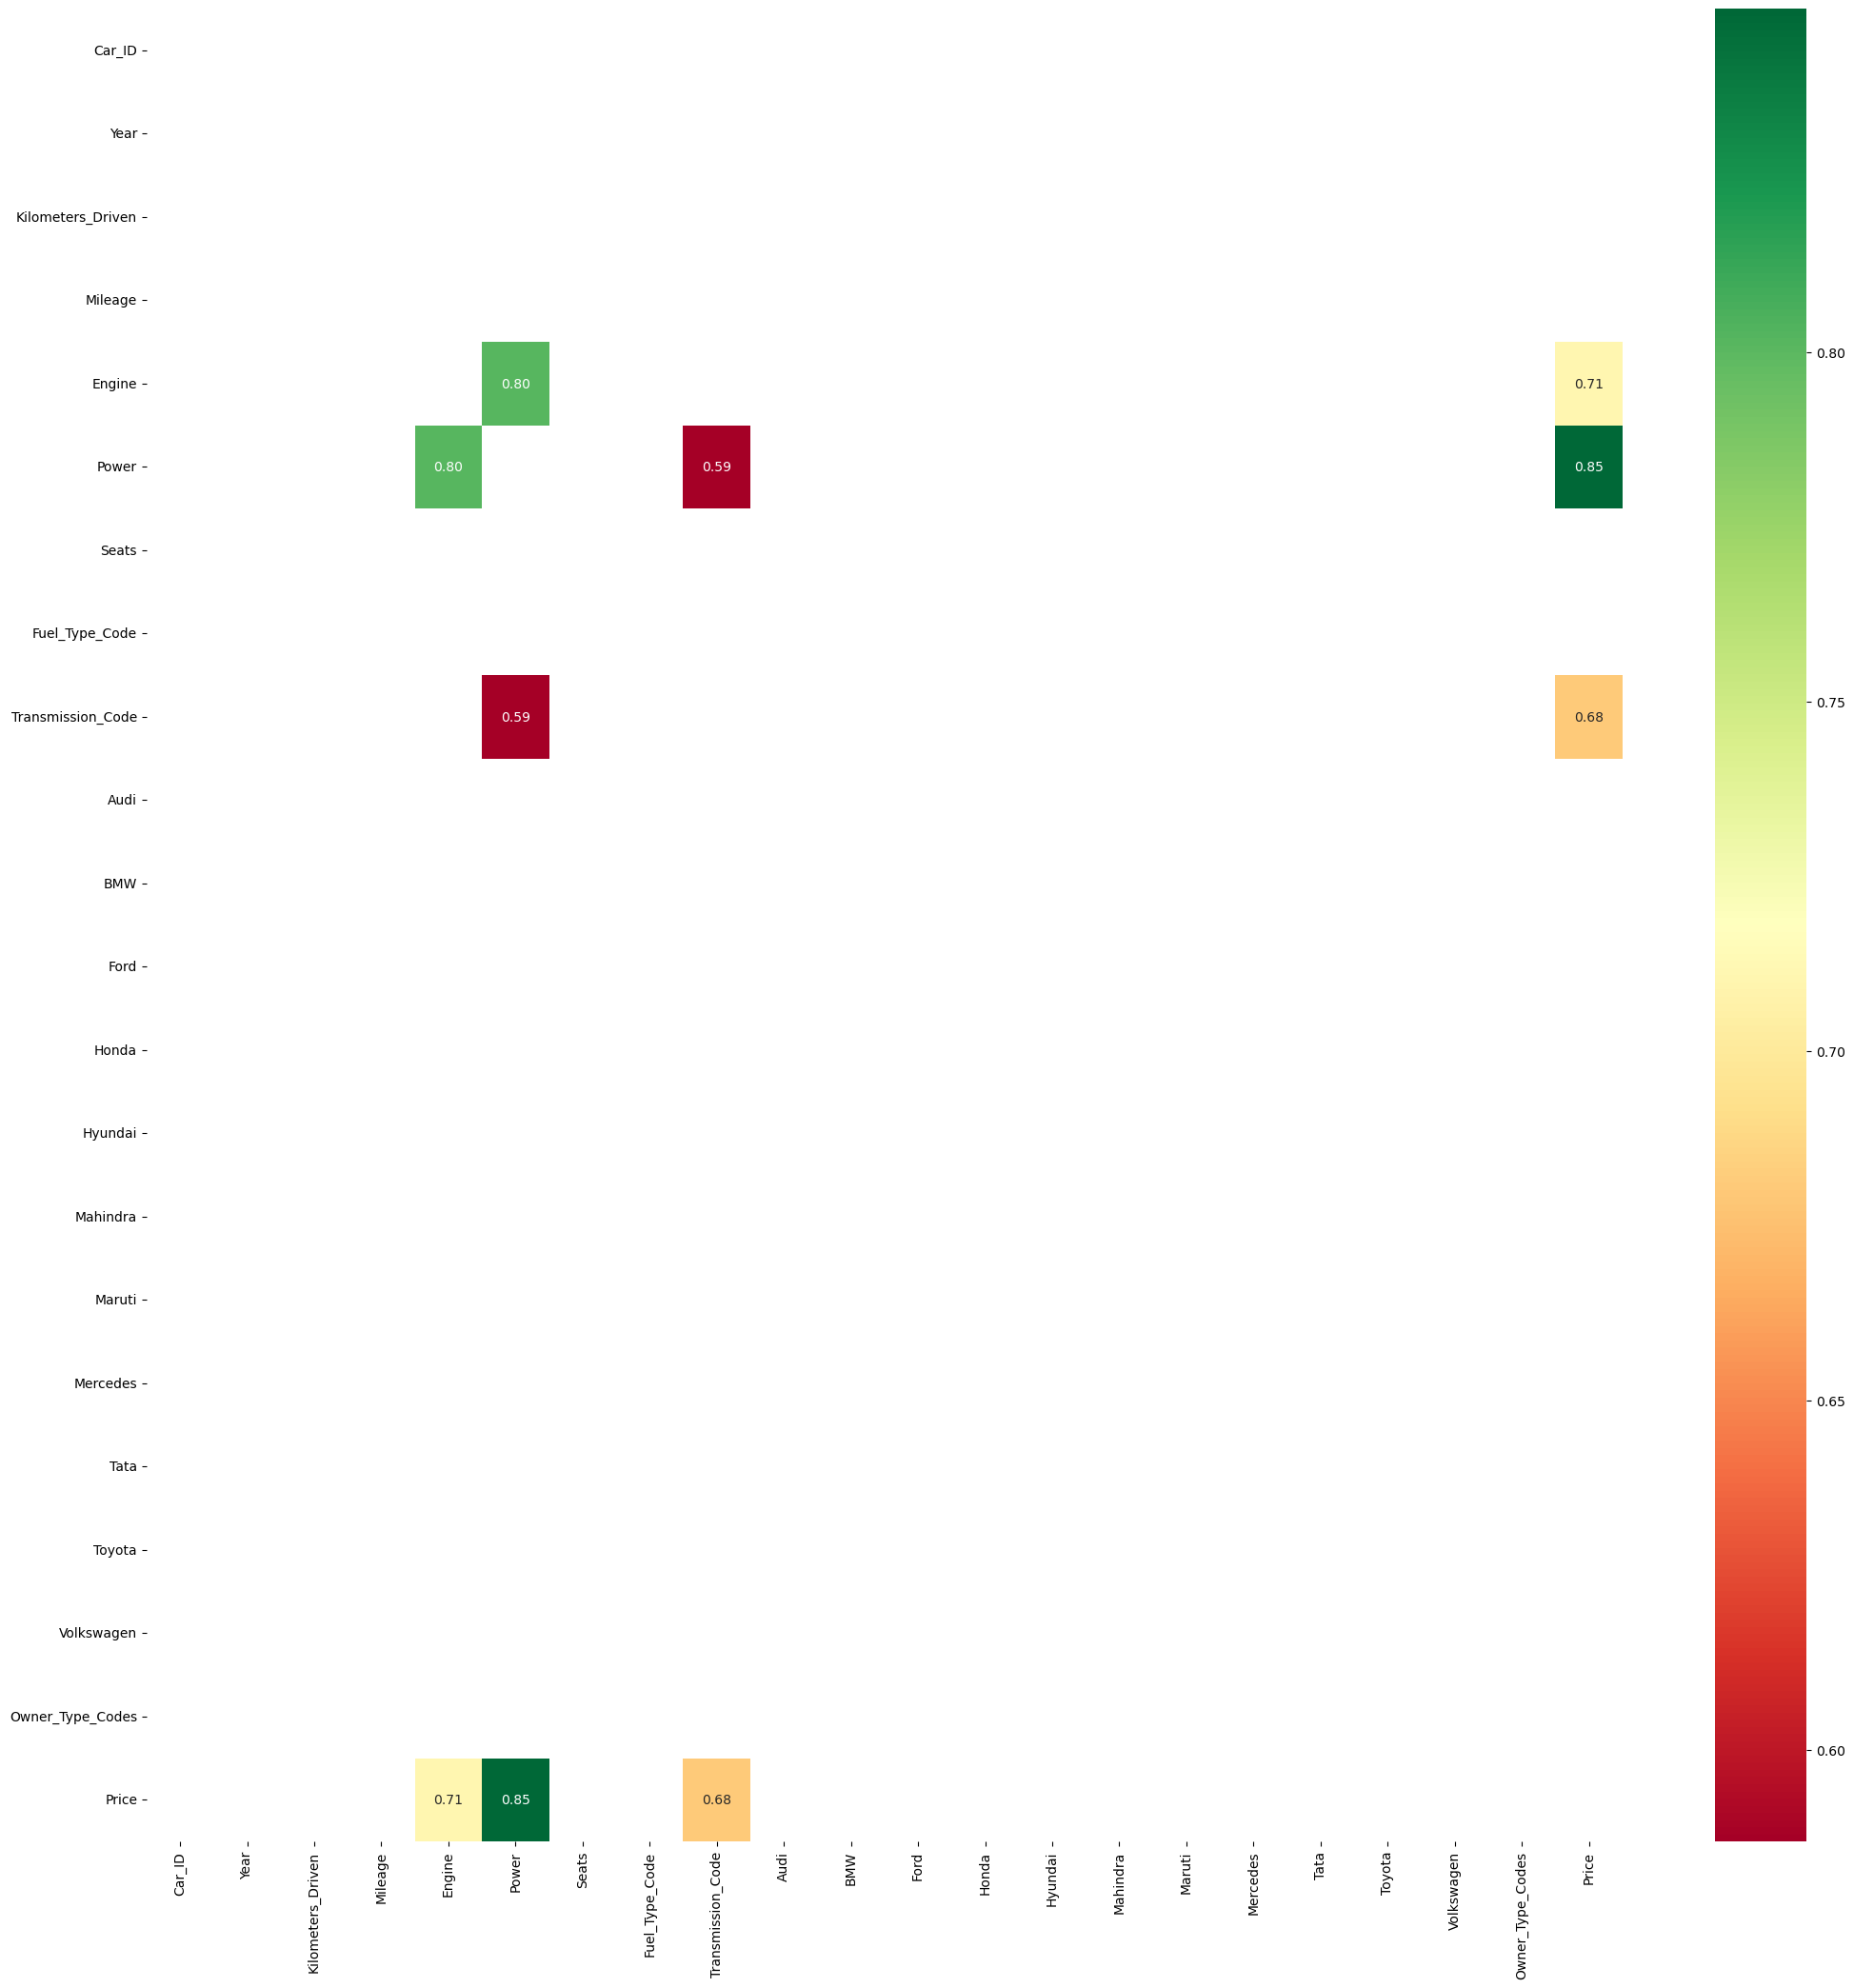

In [19]:
# Створення теплової карти для перегляду кореляцій матриці corr_X_train між 50% і 99,99%

# Налаштування розміру графіка (25 на 25 дюймів) для чіткого відображення великої матриці
plt.figure(figsize = (25, 25))

# Побудова теплової карти для кореляцій у діапазоні від 0.5 до 0.99
sns.heatmap(data = corr_X_train[(corr_X_train >= 0.5) & (corr_X_train < 0.9999)], 
            annot = True, # Відображення числових значень коефіцієнтів у клітинках
            cmap = "RdYlGn", # Колірна гама: від червоного (низька/негативна) до зеленого (висока)
            cbar = True, # Відображення бічної колірної шкали
            fmt = '.2f') # Округлення значень кореляції до двох знаків після коми

# Виведення графіка
plt.show()

In [20]:
# Аналіз матриці кореляції
print("""З матриці кореляції видно, що з цільовою змінною Price на більше, ніж 0.5 за модулем, корелюють колонки Power (0.85), 
Engine (0.71) та Transmission_Code (0.68). Помітно також те, що перелічені колонки корелюють між собою: Power, окрім Price, корелює з 
Transmission_Code (0.59) та Engine (0.80), ті ж самі кореляції спостерігаються між Transmission_Code і Power (0.59), Engine та 
Power (0.80).""")

З матриці кореляції видно, що з цільовою змінною Price на більше, ніж 0.5 за модулем, корелюють колонки Power (0.85), 
Engine (0.71) та Transmission_Code (0.68). Помітно також те, що перелічені колонки корелюють між собою: Power, окрім Price, корелює з 
Transmission_Code (0.59) та Engine (0.80), ті ж самі кореляції спостерігаються між Transmission_Code і Power (0.59), Engine та 
Power (0.80).


In [21]:
# Висновок
print("""З цільовою змінною Price на більше, ніж 0.5 за модулем, корелюють колонки Power (0.85), Engine (0.71) та Transmission_Code (0.68).""")

З цільовою змінною Price на більше, ніж 0.5 за модулем, корелюють колонки Power (0.85), Engine (0.71) та Transmission_Code (0.68).


**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресію з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [22]:
# Видалення нечислових колонок з X_train
X_train = X_train.drop(columns = X_train.select_dtypes(include = ['object']).columns)
X_train

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,2019,22000,18,1498,148,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
55,56,2018,28000,17,1968,187,5,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
26,27,2018,28000,15,1984,241,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
54,55,2017,32000,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
19,20,2017,26000,12,1991,241,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,2020,30000,23,1248,74,5,0,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,2.00
2,3,2017,20000,10,4951,395,4,1,1,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6,7,2018,45000,15,2179,140,7,0,1,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00
27,28,2019,22000,18,1995,187,5,0,1,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


In [23]:
# Видалення нечислових колонок з X_test
X_test = X_test.drop(columns = X_test.select_dtypes(include = ['object']).columns)
X_test

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,2016,38000,15,1395,148,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
41,42,2019,26000,20,1086,68,5,1,0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
92,93,2017,32000,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
14,15,2020,18000,19,1462,103,7,1,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
68,69,2019,26000,20,1194,94,5,1,0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
31,32,2017,32000,22,1582,126,5,0,1,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
89,90,2018,32000,17,1197,81,5,1,0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
15,16,2017,42000,25,1498,98,5,0,0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
21,22,2020,15000,18,1194,94,5,1,0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
60,61,2019,24000,17,1497,113,5,1,1,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


In [24]:
# Тренування лінійної регресії з sklearn на усіх числових даних тренувального набору X_train

# Визначення вхідних даних і таргету
inputs, targets = X_train, y_train
# Створення і тренування моделі
model = LinearRegression().fit(inputs, targets)

# Здійснення передбачення моделлю
predictions = model.predict(inputs)

# Обрахунок лоссу
loss = root_mean_squared_error(targets, predictions)
print('Loss (RMSE):', loss)

Loss (RMSE): 210293.5782815184


In [25]:
# Здійснення передбачення моделлю на тестових даних
predictions_test = model.predict(X_test)

# Обрахунок лоссу
loss_test = root_mean_squared_error(y_test, predictions_test)
print('Loss (RMSE) на тестових даних:', loss_test)

Loss (RMSE) на тестових даних: 258181.56112033036


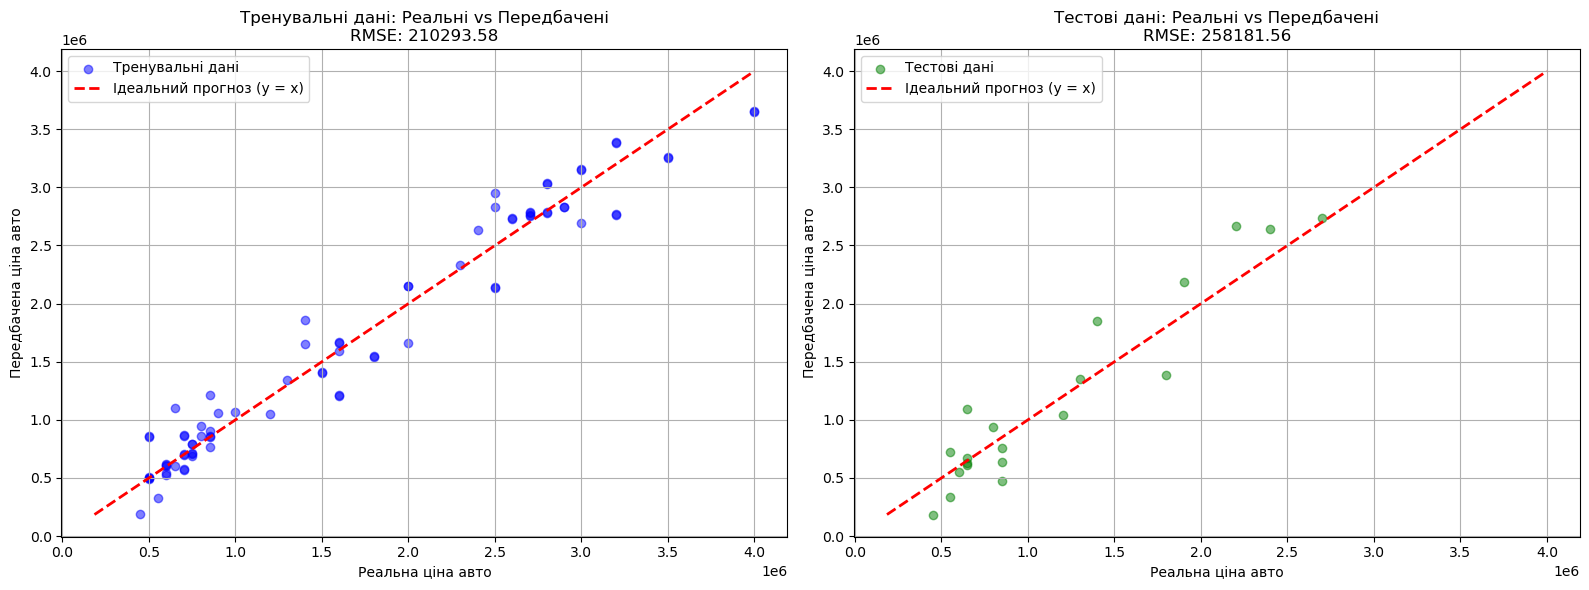

In [26]:
# Побудова графіка розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних

# Створення фігури з двома графіками поруч
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 6))

# Визначення спільних меж для обох графіків, щоб масштаби були однаковими
min_val = min(y_train.min(), y_test.min(), predictions.min(), predictions_test.min())
max_val = max(y_train.max(), y_test.max(), predictions.max(), predictions_test.max())

# Створення графіка розсіювання передбачень проти реальних даних цільової змінної для тренувального набору
ax1.scatter(y_train, predictions, color = 'blue', alpha = 0.5, label = 'Тренувальні дані')
ax1.plot([min_val, max_val], [min_val, max_val], color = 'red', linestyle = '--', lw = 2, label = 'Ідеальний прогноз (y = x)')
ax1.set_title(f'Тренувальні дані: Реальні vs Передбачені\nRMSE: {loss:.2f}')
ax1.set_xlabel('Реальна ціна авто')
ax1.set_ylabel('Передбачена ціна авто')
ax1.legend()
ax1.grid(True)

# Створення графіка розсіювання передбачень проти реальних даних цільової змінної для тестового набору
ax2.scatter(y_test, predictions_test, color = 'green', alpha = 0.5, label = 'Тестові дані')
ax2.plot([min_val, max_val], [min_val, max_val], color = 'red', linestyle = '--', lw = 2, label = 'Ідеальний прогноз (y = x)')
ax2.set_title(f'Тестові дані: Реальні vs Передбачені\nRMSE: {loss_test:.2f}')
ax2.set_xlabel('Реальна ціна авто')
ax2.set_ylabel('Передбачена ціна авто')
ax2.legend()
ax2.grid(True)

# Виведення фігури з графіками
plt.tight_layout()
plt.show()

In [27]:
# Що можете сказати про якість моделі?
print("""Оскільки як для тренувальних, так і для тестових даних точки не вишикувались чітко вздовж лінії ідеального прогнозу,
а розсіялись хмарою точок навколо цієї лінії, це свідчить про невисоку точність передбачень моделі.
На графіку передбачень для тестових даних точки розкидані трохи ширше від лінії ідеального прогнозу, ніж точки на графіку 
передбачень для тренувальних даних, тобто на тестових даних модель впоралась із передбаченнями дещо гірше. Це підтверджується 
тим, що Loss (RMSE) для тренувальних даних (210293.5782815184) дещо кращий за loss (RMSE) на тестових даних (258181.56112033036).
Отже, на підставі вищеописаних спостережень можна зробити висновок, що модель у поточному стані через низьку точність передбачень 
не підходить до використання та потребує покращення.""")

Оскільки як для тренувальних, так і для тестових даних точки не вишикувались чітко вздовж лінії ідеального прогнозу,
а розсіялись хмарою точок навколо цієї лінії, це свідчить про невисоку точність передбачень моделі.
На графіку передбачень для тестових даних точки розкидані трохи ширше від лінії ідеального прогнозу, ніж точки на графіку 
передбачень для тренувальних даних, тобто на тестових даних модель впоралась із передбаченнями дещо гірше. Це підтверджується 
тим, що Loss (RMSE) для тренувальних даних (210293.5782815184) дещо кращий за loss (RMSE) на тестових даних (258181.56112033036).
Отже, на підставі вищеописаних спостережень можна зробити висновок, що модель у поточному стані через низьку точність передбачень 
не підходить до використання та потребує покращення.


**Завдання 7**. Ми хочемо проаналізувати, як впливає кожен чинник на цільову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних, використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [28]:
# Масштабування незалежних змінних, використовуючи StandardScaler
numeric_cols = ['Car_ID', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']
scaler = StandardScaler()
scaler.fit(X_train[numeric_cols])
scaled_X_train = scaler.transform(X_train[numeric_cols])
scaled_X_test = scaler.transform(X_test[numeric_cols])

In [29]:
# Задання функції для приймання вхідних даних і таргету, створення моделї лінійної регресії, її навчання та виведення значення RMSE
def train_model_show_rmse(inputs, targets):
    """
    Створює лінійну регресію, навчає її на вхідних даних,
    виводить значення RMSE моделі.
    """
    # Ініціалізуємо та навчаємо модель
    model = LinearRegression().fit(inputs, targets)
    predictions = model.predict(inputs)
    loss = root_mean_squared_error(targets, predictions)
    print(f"Loss (RMSE) на тренувальних даних: {loss:.2f}")
    return model

# Задання категоріальних колонок
cat_cols = ['Fuel_Type_Code', 'Transmission_Code', 'Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 
            'Maruti', 'Mercedes', 'Tata', 'Toyota', 'Volkswagen', 'Owner_Type_Codes']
categorical_data = X_train[cat_cols].values
inputs = np.concatenate((scaled_X_train, categorical_data), axis = 1)
targets = y_train
model = train_model_show_rmse(inputs, targets)
column_names = numeric_cols + cat_cols
inputs_df = pd.DataFrame(inputs, columns = column_names)

# Перегляд коефіцієнтів моделі
weights_df = pd.DataFrame({
    'feature': np.append(numeric_cols + cat_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df.sort_values('weight', ascending = False)

Loss (RMSE) на тренувальних даних: 210293.58


,feature,weight
21,1,1601955.69
9,Audi,756997.39
16,Mercedes,736415.67
10,BMW,731220.83
5,Power,496769.21
8,Transmission_Code,239529.37
18,Toyota,124349.23
20,Owner_Type_Codes,64763.99
0,Car_ID,5608.69
6,Seats,-2148.92


In [30]:
# Перевірка поведінки моделі на тестових даних

# Підготовка тестових категоріальних даних
categorical_data_test = X_test[cat_cols].values

# Об'єднання масштабованих тестових числових і тестових категоріальних ознак
inputs_test = np.concatenate((scaled_X_test, categorical_data_test), axis = 1)

# Здійснення передбачень на тестових даних за допомогою вже навченої моделі
predictions_test = model.predict(inputs_test)

# Обрахунок та виведення лоссу на тестових даних
loss_test = root_mean_squared_error(y_test, predictions_test)
print(f"Loss (RMSE) на тестових даних: {loss_test:.2f}")

Loss (RMSE) на тестових даних: 258181.56


In [31]:
# Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? 
print("""З точки зору коефіцієнтів, найвпливовішими на формування передбачення є колонки (у порядку спадання): 1 (константа), 
Audi, Mercedes, BMW, Mahindra, Hyundai, Power, Maruti, Fuel_Type_Code, Ford, Volkswagen, Transmission_Code, Honda, Mileage,
Tata, Toyota.""")

# Аналіз напряму дії найважливіших коефіцієнтів
print("""Як видно з отриманих коефіцієнтів, в бік підвищення ціни авто діють: 1 (константа), бренди Audi, Mercedes, BMW і 
Toyota, максимальна потужність автомобіля в кінських силах (Power) та тип трансмісії (Transmission_Code, де автоматична 
трансмісія - 1, механічна - 0).
В бік зниження ціни авто діють такі коефіцієнти, як: бренди Mahindra, Hyundai, Maruti, Ford, Volkswagen, Honda, Mileage і Tata, 
а також тип палива (Fuel_Type_Code, де бензин - 1, дизель - 0).""")

З точки зору коефіцієнтів, найвпливовішими на формування передбачення є колонки (у порядку спадання): 1 (константа), 
Audi, Mercedes, BMW, Mahindra, Hyundai, Power, Maruti, Fuel_Type_Code, Ford, Volkswagen, Transmission_Code, Honda, Mileage,
Tata, Toyota.
Як видно з отриманих коефіцієнтів, в бік підвищення ціни авто діють: 1 (константа), бренди Audi, Mercedes, BMW і 
Toyota, максимальна потужність автомобіля в кінських силах (Power) та тип трансмісії (Transmission_Code, де автоматична 
трансмісія - 1, механічна - 0).
В бік зниження ціни авто діють такі коефіцієнти, як: бренди Mahindra, Hyundai, Maruti, Ford, Volkswagen, Honda, Mileage і Tata, 
а також тип палива (Fuel_Type_Code, де бензин - 1, дизель - 0).


In [32]:
# Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?
print("""З точки зору значення відповідних змінних, у впливі коефіцієнтів на ціну авто простежується логіка, адже дійсно мають вищу ціну 
автомобілі брендів, що позиціонують себе, як преміум-сегмент, з вищою максимальною потужністю автомобіля в кінських силах та 
з автоматичною трансмісією. Стосовно нижчої ціни, її теж насправді мають автомобілі економ-класу або маловідомих брендів та на 
бензиновому паливі (порівняно з установкою для дизельного палива, яка здорожчує авто).""")

З точки зору значення відповідних змінних, у впливі коефіцієнтів на ціну авто простежується логіка, адже дійсно мають вищу ціну 
автомобілі брендів, що позиціонують себе, як преміум-сегмент, з вищою максимальною потужністю автомобіля в кінських силах та 
з автоматичною трансмісією. Стосовно нижчої ціни, її теж насправді мають автомобілі економ-класу або маловідомих брендів та на 
бензиновому паливі (порівняно з установкою для дизельного палива, яка здорожчує авто).


**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [33]:
# Тренування моделі зі statsmodels, виведення звіту й аналіз p-value коефіцієнтів

# Тренування моделі зі statsmodels
Y = targets.values  # y_train, перетворений на масив NumPy, щоб скинути індекси
X = inputs_df.copy() # копія inputs_df з назвами колонок (numeric_cols + cat_cols)

# Скидання індексів для X, щоб вони гарантовано починалися від 0 до N, як і в масиві Y
X.index = range(len(Y))

# Додавання константи (стовпець із одиничками)
X = sm.add_constant(X)

# Тренування моделі
model = sm.OLS(Y, X)
results = model.fit()

# Виведення результату з назвами колонок
print(results.params)

const               1468459.39
Car_ID                 5608.69
Year                  -8765.65
Kilometers_Driven    -94398.72
Mileage             -131715.51
Engine               -21377.45
Power                496769.21
Seats                 -2148.92
Fuel_Type_Code      -367811.00
Transmission_Code    239529.37
Audi                 890493.69
BMW                  864717.14
Ford                -168943.62
Honda                -54084.23
Hyundai             -373085.65
Mahindra            -441540.89
Maruti              -258606.51
Mercedes             869911.98
Tata                   5605.97
Toyota               257845.54
Volkswagen          -123854.03
Owner_Type_Codes      64763.99
dtype: float64


In [34]:
# Виведення звіту
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     68.35
Date:                Fri, 03 Jul 2026   Prob (F-statistic):           2.01e-33
Time:                        16:33:05   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2230.
Df Residuals:                      59   BIC:                             2280.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.468e+06   7.26e+0

In [35]:
# Аналіз p-value коефіцієнтів
print("""Дивлячись на p-value коефіцієнтів, ми бачимо, що переважна кількість ознак є статистично значущими, оскільки для них 
p-value < 0.05. На це ж саме вказують високі показники R-squared: 0.959 (95.9%) та Adj. R-squared: 0.945 (94.5%) для моделі. Вони означають, 
що наявні ознаки описують приблизно 95% усього розкиду цін на автомобілі, тобто велика кількість змінних у моделі загалом є виправданою.""")

Дивлячись на p-value коефіцієнтів, ми бачимо, що переважна кількість ознак є статистично значущими, оскільки для них 
p-value < 0.05. На це ж саме вказують високі показники R-squared: 0.959 (95.9%) та Adj. R-squared: 0.945 (94.5%) для моделі. Вони означають, 
що наявні ознаки описують приблизно 95% усього розкиду цін на автомобілі, тобто велика кількість змінних у моделі загалом є виправданою.


In [36]:
# Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.
print("""Статистично значущими на рівні значущості 0.05 є такі ознаки: const, Mileage, Power, Fuel_Type_Code, Transmission_Code, Audi, BMW, 
Hyundai, Mahindra, Maruti, Mercedes, Toyota.""")

Статистично значущими на рівні значущості 0.05 є такі ознаки: const, Mileage, Power, Fuel_Type_Code, Transmission_Code, Audi, BMW, 
Hyundai, Mahindra, Maruti, Mercedes, Toyota.


**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [37]:
# Тренування моделі зі statsmodels на статистично значущих ознаках, виведення звіту й аналіз p-value коефіцієнтів

# Визначення списку статистично значущих ознак
significant_cols = ['const', 'Mileage', 'Power', 'Fuel_Type_Code', 'Transmission_Code', 
    'Audi', 'BMW', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Toyota']

# Тренування моделі зі statsmodels
Y = targets.values  # y_train, перетворений на масив NumPy, щоб скинути індекси
X_full = inputs_df.copy() # копія inputs_df з назвами колонок (numeric_cols + cat_cols)

# Скидання індексів для X, щоб вони гарантовано починалися від 0 до N, як і в масиві Y
X_full.index = range(len(Y))

# Додавання константи (стовпець із одиничками)
X_full = sm.add_constant(X_full)

# Фільтрація значущих колонок
X_significant = X_full[significant_cols]

# Тренування моделі на урізаному наборі ознак
reduced_model = sm.OLS(Y, X_significant)
reduced_results = reduced_model.fit()

# Виведення результату з назвами колонок
print(reduced_results.params)

const               1347926.03
Mileage              -98714.69
Power                462607.86
Fuel_Type_Code      -264434.72
Transmission_Code    254645.06
Audi                 966467.53
BMW                 1060240.47
Hyundai             -307347.64
Mahindra            -285940.66
Maruti              -117807.49
Mercedes            1017277.28
Toyota               259702.45
dtype: float64


In [38]:
# Виведення звіту
print(reduced_results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     129.2
Date:                Fri, 03 Jul 2026   Prob (F-statistic):           4.53e-41
Time:                        16:33:05   Log-Likelihood:                -1098.0
No. Observations:                  80   AIC:                             2220.
Df Residuals:                      68   BIC:                             2248.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.348e+06   6.68e+0

In [39]:
# Створення списку ознак для тесту (без колонки 'const', бо вона буде додана через sm.add_constant)
test_features = [col for col in significant_cols if col != 'const']

# Створення тестового датафрейму з масштабованими числовими й категоріальними ознаками
inputs_test_df = pd.DataFrame(inputs_test, columns = column_names)

# Додавання константи та відбір лише значущих колонок для тесту
X_test_full = sm.add_constant(inputs_test_df)
X_test_significant = X_test_full[significant_cols]

# Здійснення передбачення новою моделлю
predictions_test_reduced = reduced_results.predict(X_test_significant)

# Обрахунок нового тестового лоссу
new_loss_test = root_mean_squared_error(y_test, predictions_test_reduced)

# Обрахунок нового тренувального лоссу для порівняння
predictions_train_reduced = reduced_results.predict(X_significant)
new_loss_train = root_mean_squared_error(y_train, predictions_train_reduced)

print(f"Новий Loss (RMSE) на тренувальних даних: {new_loss_train:.2f}")
print(f"Новий Loss (RMSE) на тестових даних: {new_loss_test:.2f}")

Новий Loss (RMSE) на тренувальних даних: 220898.60
Новий Loss (RMSE) на тестових даних: 253952.69


In [40]:
# Аналіз показників моделі. Чи значно змінились R2 і Adj. R-squared?
print("""З показників звіту для моделі бачимо, що R-squared: 0.954 (95.4%) залишився майже таким самим. 
Це означає, що відібрані статистично значущі змінні так само описують приблизно 95% усього розкиду цін на автомобілі, як 
і в попередній моделі. Adj. R-squared: 0.947 (94.7%) показав незначне збільшення, яке доводить, що вилучені ознаки дійсно 
були зайвим "шумом". 
Після вилучення змінних, які не є статистично значущими, значення функції втрат змінилися наступним чином: 
на тренувальних даних лосс зріс з 210293.58 до 220898.60, оскільки модель більше не підлаштовується під ознаки, що не мають 
реального впливу на цільову змінну. Лосс на тестових даних зменшився з 258181.56 до 253952.69, тобто результативність 
моделі на нових для неї даних покращилась.
Враховуючи вищевказані спостереження, можемо зробити висновок, що модель лінійної регресії на новому наборі даних лише зі
статистично значущими змінними є кращою за попередню модель, натреновану на всіх ознаках. Нова модель так само покриває практично 
весь розкид цін на автомобілі й, як видно зі зменшення тестового лоссу, робить передбачення, більш близькі до реальних даних.""")

З показників звіту для моделі бачимо, що R-squared: 0.954 (95.4%) залишився майже таким самим. 
Це означає, що відібрані статистично значущі змінні так само описують приблизно 95% усього розкиду цін на автомобілі, як 
і в попередній моделі. Adj. R-squared: 0.947 (94.7%) показав незначне збільшення, яке доводить, що вилучені ознаки дійсно 
були зайвим "шумом". 
Після вилучення змінних, які не є статистично значущими, значення функції втрат змінилися наступним чином: 
на тренувальних даних лосс зріс з 210293.58 до 220898.60, оскільки модель більше не підлаштовується під ознаки, що не мають 
реального впливу на цільову змінну. Лосс на тестових даних зменшився з 258181.56 до 253952.69, тобто результативність 
моделі на нових для неї даних покращилась.
Враховуючи вищевказані спостереження, можемо зробити висновок, що модель лінійної регресії на новому наборі даних лише зі
статистично значущими змінними є кращою за попередню модель, натреновану на всіх ознаках. Нова модель так само покриває 

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [41]:
# Тренування моделі зі statsmodels на статистично значущих ознаках, у яких p_value в завданні 8 менше за 0.25, 
# виведення звіту й аналіз p-value коефіцієнтів

# Визначення списку статистично значущих ознак
significant_cols = ['const', 'Kilometers_Driven', 'Mileage', 'Power', 'Fuel_Type_Code', 'Transmission_Code', 
    'Audi', 'BMW', 'Ford', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Toyota']

# Тренування моделі зі statsmodels
Y = targets.values  # y_train, перетворений на масив NumPy, щоб скинути індекси
X_full = inputs_df.copy() # копія inputs_df з назвами колонок (numeric_cols + cat_cols)

# Скидання індексів для X, щоб вони гарантовано починалися від 0 до N, як і в масиві Y
X_full.index = range(len(Y))

# Додавання константи (стовпець із одиничками)
X_full = sm.add_constant(X_full)

# Фільтрація значущих колонок
X_significant = X_full[significant_cols]

# Тренування моделі на урізаному наборі ознак
reduced_model = sm.OLS(Y, X_significant)
reduced_results = reduced_model.fit()

# Виведення результату з назвами колонок
print(reduced_results.params)

const               1410132.46
Kilometers_Driven    -78111.57
Mileage             -121858.28
Power                466718.41
Fuel_Type_Code      -323817.96
Transmission_Code    235620.32
Audi                 962906.32
BMW                  976232.26
Ford                 -51191.83
Hyundai             -264696.70
Mahindra            -352043.85
Maruti              -168553.62
Mercedes             961618.09
Toyota               309561.24
dtype: float64


In [42]:
# Виведення звіту
print(reduced_results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     115.3
Date:                Fri, 03 Jul 2026   Prob (F-statistic):           4.40e-40
Time:                        16:33:05   Log-Likelihood:                -1094.8
No. Observations:                  80   AIC:                             2218.
Df Residuals:                      66   BIC:                             2251.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.41e+06   8.43e+0

In [43]:
# Створення списку ознак для тесту (без колонки 'const', бо вона буде додана через sm.add_constant)
test_features = [col for col in significant_cols if col != 'const']

# Створення тестового датафрейму з масштабованими числовими й категоріальними ознаками
inputs_test_df = pd.DataFrame(inputs_test, columns = column_names)

# Додавання константи та відбір лише значущих колонок для тесту
X_test_full = sm.add_constant(inputs_test_df)
X_test_significant = X_test_full[significant_cols]

# Здійснення передбачення новою моделлю
predictions_test_reduced = reduced_results.predict(X_test_significant)

# Обрахунок нового тестового лоссу
new_loss_test = root_mean_squared_error(y_test, predictions_test_reduced)

# Обрахунок нового тренувального лоссу для порівняння
predictions_train_reduced = reduced_results.predict(X_significant)
new_loss_train = root_mean_squared_error(y_train, predictions_train_reduced)

print(f"Новий Loss (RMSE) на тренувальних даних: {new_loss_train:.2f}")
print(f"Новий Loss (RMSE) на тестових даних: {new_loss_test:.2f}")

Новий Loss (RMSE) на тренувальних даних: 212333.75
Новий Loss (RMSE) на тестових даних: 249807.05


In [44]:
# Аналіз показників моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8?
print("""З показників звіту для моделі бачимо, що R-squared: 0.958 (95.8%) практично не змінився, тобто відібрані 
статистично значущі змінні так само описують приблизно 96% усього розкиду цін на автомобілі, як і в моделі з завдання 8. 
Adj. R-squared: 0.95 (95%) має незначне збільшення, яке показує, що вилучені ознаки дійсно були зайвим "шумом". 
Значення функції втрат, порівняно з моделлю із завдання 8, змінилися наступним чином: на тренувальних даних лосс 
дещо зріс з 210293.58 до 212333.75, оскільки модель більше не підлаштовується під ознаки, які не є статистично 
значущими. Лосс на тестових даних зменшився з 258181.56 до 249807.05, тобто результативність моделі на нових 
для неї даних покращилась.
З вищенаведених спостережень можемо зробити висновок, що модель лінійної регресії на новому наборі даних зі статистично 
значущими змінними (у яких p_value в завданні 8 менше за 0.25) є кращою за модель із завдання 8, натреновану на всіх ознаках. 
Нова модель так само покриває весь розкид цін на автомобілі й, як видно зі зменшення тестового лоссу, робить передбачення, 
більш близькі до реальних даних.""")

З показників звіту для моделі бачимо, що R-squared: 0.958 (95.8%) практично не змінився, тобто відібрані 
статистично значущі змінні так само описують приблизно 96% усього розкиду цін на автомобілі, як і в моделі з завдання 8. 
Adj. R-squared: 0.95 (95%) має незначне збільшення, яке показує, що вилучені ознаки дійсно були зайвим "шумом". 
Значення функції втрат, порівняно з моделлю із завдання 8, змінилися наступним чином: на тренувальних даних лосс 
дещо зріс з 210293.58 до 212333.75, оскільки модель більше не підлаштовується під ознаки, які не є статистично 
значущими. Лосс на тестових даних зменшився з 258181.56 до 249807.05, тобто результативність моделі на нових 
для неї даних покращилась.
З вищенаведених спостережень можемо зробити висновок, що модель лінійної регресії на новому наборі даних зі статистично 
значущими змінними (у яких p_value в завданні 8 менше за 0.25) є кращою за модель із завдання 8, натреновану на всіх ознаках. 
Нова модель так само покриває весь розкид цін на

In [45]:
# Яку модель з останніх 3х завдань ви б лишили для використання?
print("""Порівнявши між собою показники статистичних звітів та значення функції втрат для тренувальних і тестових даних 
усіх трьох моделей, можна зробити наступні висновки:
1. За покриттям розкиду цін на автомобілі (R-squared та Adj. R-squared) всі 3 моделі показали дуже схожі результати з незначними 
відмінностями (95-96%). Нижчий результат тут у моделі, натренованої лише на статистично значущих ознаках (у яких p_value в 
завданні 8 менше за 0.05), бо з неї було вилучено найбільше ознак. Інші дві моделі - на одному рівні (96%).
2. За результативністю передбачень на тестових даних найгірше показала себе модель із завдання 8, натренована на всіх ознаках 
(Loss (RMSE) на тренувальних даних: 210293.58, Loss (RMSE) на тестових даних: 258181.56).
3. Модель, натренована на статистично значущих ознаках, у яких p_value в завданні 8 менше за 0.05 (Loss (RMSE) на тренувальних даних: 
220898.60, Loss (RMSE) на тестових даних: 253952.69), зробила передбачення на тестових даних краще за модель із завдання 8 з усіма 
ознаками, але гірше за останню модель з ознаками, у яких p_value в завданні 8 менше за 0.25.
4. Найкращою для використання з цих 3 моделей виглядає модель із завдання 10, натренована на ознаках, у яких p_value в завданні 8 
менше за 0.25 (Loss (RMSE) на тренувальних даних: 212333.75, Loss (RMSE) на тестових даних: 249807.05), оскільки вона показала 
найменший лосс на тестових даних та лосс на тренувальних даних, близький до найменшого 210293.58 для моделі з усіма ознаками, 
а також покрила найбільший розкид цін на автомобілі (96%).""")

Порівнявши між собою показники статистичних звітів та значення функції втрат для тренувальних і тестових даних 
усіх трьох моделей, можна зробити наступні висновки:
1. За покриттям розкиду цін на автомобілі (R-squared та Adj. R-squared) всі 3 моделі показали дуже схожі результати з незначними 
відмінностями (95-96%). Нижчий результат тут у моделі, натренованої лише на статистично значущих ознаках (у яких p_value в 
завданні 8 менше за 0.05), бо з неї було вилучено найбільше ознак. Інші дві моделі - на одному рівні (96%).
2. За результативністю передбачень на тестових даних найгірше показала себе модель із завдання 8, натренована на всіх ознаках 
(Loss (RMSE) на тренувальних даних: 210293.58, Loss (RMSE) на тестових даних: 258181.56).
3. Модель, натренована на статистично значущих ознаках, у яких p_value в завданні 8 менше за 0.05 (Loss (RMSE) на тренувальних даних: 
220898.60, Loss (RMSE) на тестових даних: 253952.69), зробила передбачення на тестових даних краще за модель із завдання 